<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/CNN_Computer_Vision/03_DCL_Treinamento_de_Anotacoes_Frames.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Objetivo desta etapa:
- Treinar a arquitetura ResNet-50 para reconhecer pontos anatômicos (cascos/articulações) nos frames selecionados. O resultado esperado é uma rede capaz de automatizar a anotação dos frames restantes do vídeo. Analisar a aplicação de hiperparâmetros diferentes, análise de métricas e diversidade de banco de dados.
- Treinamentos serão feitos com dados locais, para uma melhor performance e maior velocidade, em seguida copiados no Drive.
- Criação de gráfico Loss para verificar a performance de treino.
- Análise, métricas de treino e validação, estarão no arquivo PerformanceIndicators.md do repositório: https://github.com/vitoriaferreirap/DeepLearning/blob/main/PerformanceIndicators.md


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Tras arquivos do drive para ambiente local

# Entra na pasta do projeto no Drive
%cd /content/drive/MyDrive/deeplabcut/

# Comprime a pasta inteira em um arquivo único chamado 'projeto_local.zip'
# O -r é para ser recursivo (pegar subpastas) e o -q é para não encher a tela de texto
!zip -r -q projeto_backup.zip EstimativaPose_LOCAL

# Confirma se o arquivo foi criado
!ls -lh projeto_backup.zip

/content/drive/MyDrive/deeplabcut
-rw------- 1 root root 3.0G Mar 10 16:22 projeto_backup.zip


In [ ]:
# Copia o ZIP novo do drive para o colab
!cp /content/drive/MyDrive/deeplabcut/projeto_local.zip /content/


In [1]:
# Extrai arquivos zipados
!unzip -q /content/EstimativaPose_LOCAL.zip -d /content/

In [2]:
!pip install --pre deeplabcut

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.5 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 108.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━

In [1]:
import deeplabcut

Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


## Create a training dataset:
- Mesmo continuando com o conhecimento do treino anterior, tecnicamente para o DeepLabCut isso é considerado um novo conjunto de treinamento porque a (os dados que o modelo vai ler) mudou: agora ela contém as correções dos cascos e as remoções de pontos ocluídos corrigidos manualmente.


In [2]:
path_config_local = 'EstimativaPose_LOCAL/config.yaml'
# O parâmetro 'iteration=1' deve ser o padrão se o merge funcionou
deeplabcut.create_training_dataset(
    path_config_local,
    net_type="resnet_50",
    num_shuffles=1,
    engine=deeplabcut.Engine.PYTORCH,
    augmenter_type='imgaug'
)

[(0.95,
  1,
  (array([118,  64,  90, 201, 257, 214, 204, 249,  15,  22,  81, 265,  12,
          221,  59, 158, 266, 134,  45, 137, 154, 230, 194, 216, 146, 150,
           89, 160, 245, 253, 126,   8,   5,  76, 237, 122, 101,   7, 159,
          106,  63, 212, 207, 223,  55, 219,  92, 175, 250, 269,  73,  74,
          217,  20,  46, 278, 208, 176, 200, 157,  27, 173, 178, 199, 238,
           37, 156, 239, 209, 129, 255, 184,  97, 218, 161, 111, 268,  44,
          222, 139, 110, 116,  54, 228,  18, 152, 229, 103, 227,  71, 182,
          224, 187, 272, 189,  33,  83, 136,  60, 210, 264,  21,  29, 232,
           16,  56,  75, 135, 155, 145, 109, 188,   4,  96, 153,  61, 108,
           67,  52,  66,  26, 124, 181, 166, 263,  40, 205,  13, 107, 277,
            3, 144, 125,  24,  30,  77, 262, 171,  19, 231, 275, 247,  80,
           51,   2, 215, 104, 234,  86,  10, 258,  58,  41,  14,  50, 279,
          213, 123,  62, 282, 206, 130, 190, 168,  43, 240, 138, 179, 198,
          14

In [3]:
project_folder_local = "EstimativaPose_LOCAL"

videofile_path = [
  f"/content/{project_folder_local}/videos/1.mp4",
  f"/content/{project_folder_local}/videos/2.mp4",
  f"/content/{project_folder_local}/videos/3.mp4",
  f"/content/{project_folder_local}/videos/4.mp4",
  f"/content/{project_folder_local}/videos/5.mp4",
  f"/content/{project_folder_local}/videos/6.mp4",
  f"/content/{project_folder_local}/videos/7.mp4",
  f"/content/{project_folder_local}/videos/8.mp4",
  f"/content/{project_folder_local}/videos/9.mp4",
  f"/content/{project_folder_local}/videos/10.mp4"
]

# Onde os vídeos analisados serão salvos temporariamente
destfolder = f"/content/{project_folder_local}/labeled-videos"

# O arquivo de configuração que o DeepLabCut vai ler para o treino
path_config_file = f"/content/{project_folder_local}/config.yaml"

print(f"Caminho do Config Local: {path_config_file}")
print(f"Primeiro vídeo local: {videofile_path[0]}")

Caminho do Config Local: /content/EstimativaPose_LOCAL/config.yaml
Primeiro vídeo local: /content/EstimativaPose_LOCAL/videos/1.mp4


## Treinamento

In [4]:
deeplabcut.train_network(
    path_config_file,
    shuffle=1,
    trainingsetindex=0,
    device="cuda:0",
    max_snapshots_to_keep=5,
    displayiters=50,
    save_epochs=50,
    epochs=200,
    saveiters=50
)

Training with configuration:
data:
  bbox_margin: 20
  colormode: RGB
  inference:
    normalize_images: True
  train:
    affine:
      p: 0.5
      rotation: 30
      scaling: [0.5, 1.25]
      translation: 0
    crop_sampling:
      width: 448
      height: 448
      max_shift: 0.1
      method: hybrid
    gaussian_noise: 12.75
    motion_blur: True
    normalize_images: True
device: auto
inference:
  multithreading:
    enabled: True
    queue_length: 4
    timeout: 30.0
  compile:
    enabled: False
    backend: inductor
  autocast:
    enabled: False
metadata:
  project_path: /content/EstimativaPose_LOCAL
  pose_config_path: /content/EstimativaPose_LOCAL/dlc-models-pytorch/iteration-1/EstimativaPoseMar6-trainset95shuffle1/train/pytorch_config.yaml
  bodyparts: ['Ext_Joelho', 'Ext_CanelaDianteira', 'Ext_CascoDianteiro', 'Ext_Perna', 'Ext_Jarrete', 'Ext_CanelaTraseira', 'Ext_CascoTraseiro', 'Int_Joelho', 'Int_CanelaDianteira', 'Int_CascoDianteiro', 'Int_Perna', 'Int_Jarrete', 'Int_

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

[timm/resnet50_gn.a1h_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
Data Transforms:
  Training:   Compose([
  Affine(always_apply=False, p=0.5, interpolation=1, mask_interpolation=0, cval=0, mode=0, scale={'x': (0.5, 1.25), 'y': (0.5, 1.25)}, translate_percent=None, translate_px={'x': (0, 0), 'y': (0, 0)}, rotate=(-30, 30), fit_output=False, shear={'x': (0.0, 0.0), 'y': (0.0, 0.0)}, cval_mask=0, keep_ratio=True, rotate_method='largest_box'),
  PadIfNeeded(always_apply=True, p=1.0, min_height=448, min_width=448, pad_height_divisor=None, pad_width_divisor=None, position=PositionType.CENTER, border_mode=0, value=None, mask_value=None),
  KeypointAwareCrop(always_apply=True, p=1.0, width=448, height=448, max_shift=0.1, crop_sampling='hybrid'),
  MotionBlur(always_apply=False, p=0.5, blur_limit=(3, 7), allow_shifted=True),
  GaussNoise(always_apply=False, p=0.5, var_limit=(0, 162.5625), per_channel=True, mean=0),
  Nor

## Avalia o treino (Gera os gráficos de erro/RMSE)



In [5]:
# pcutof aogra 0.8
deeplabcut.evaluate_network(path_config_file, plotting=True, Shuffles=[1])

Evaluation scorer: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140


100%|██████████| 15/15 [00:03<00:00,  4.00it/s]


Evaluation results file: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140-results.csv
Evaluation results for DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140-results.csv (pcutoff: 0.8):
train rmse             89.82
train rmse_pcutoff      3.26
train mAP              38.10
train mAR              45.19
test rmse             118.68
test rmse_pcutoff       4.22
test mAP               38.72
test mAR               44.67
Name: (0.95, 1, 140, -1, 0.8), dtype: float64


## Análise vídeos:
Esta função analisa o novo vídeo. O usuário pode escolher o melhor modelo a partir dos resultados da avaliação e especificar o índice correto do snapshot para a variável ` snapshotindex` no arquivo `config.yaml` . Caso contrário, por padrão, o snapshot mais recente é usado para analisar o vídeo.

Os resultados são armazenados em um arquivo hd5 no mesmo diretório onde o vídeo está localizado.

In [6]:
# Analisa o vídeo (Gera o arquivo .h5 com as predições do modelo)
deeplabcut.analyze_videos(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
    gputouse=0
)

Analyzing videos with /content/EstimativaPose_LOCAL/dlc-models-pytorch/iteration-1/EstimativaPoseMar6-trainset95shuffle1/train/snapshot-best-140.pt
Using scorer: DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140
Starting to analyze /content/EstimativaPose_LOCAL/videos/9.mp4
Video metadata: 
  Overall # of frames:    69
  Duration of video [s]:  4.60
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 69/69 [00:07<00:00,  8.75it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/9DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140.h5 and /content/EstimativaPose_LOCAL/labeled-videos/9DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/3.mp4
Video metadata: 
  Overall # of frames:    54
  Duration of video [s]:  3.60
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 54/54 [00:03<00:00, 15.75it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/3DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140.h5 and /content/EstimativaPose_LOCAL/labeled-videos/3DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/1.mp4
Video metadata: 
  Overall # of frames:    78
  Duration of video [s]:  5.20
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


...

100%|██████████| 56/56 [00:05<00:00, 10.48it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/5DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140.h5 and /content/EstimativaPose_LOCAL/labeled-videos/5DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140_full.pickle
Starting to analyze /content/EstimativaPose_LOCAL/videos/4.mp4
Video metadata: 
  Overall # of frames:    62
  Duration of video [s]:  4.13
  fps:                    15.0
  resolution:             w=2208, h=1242

Running pose prediction with batch size 8


100%|██████████| 62/62 [00:05<00:00, 10.94it/s]


Saving results in /content/EstimativaPose_LOCAL/labeled-videos/4DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140.h5 and /content/EstimativaPose_LOCAL/labeled-videos/4DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140_full.pickle
The videos are analyzed. Now your research can truly start!
You can create labeled videos with 'create_labeled_video'.
If the tracking is not satisfactory for some videos, consider expanding the training set. You can use the function 'extract_outlier_frames' to extract a few representative outlier frames.



'DLC_Resnet50_EstimativaPoseMar6shuffle1_snapshot_best-140'

In [2]:
# Extrai os frames ruins (Gera as imagens .png dos erros)
deeplabcut.extract_outlier_frames(
    path_config_file,
    videofile_path,
    outlieralgorithm='uncertain',
    p_bound=0.8,
    automatic=True
)

NameError: name 'deeplabcut' is not defined

## Trace as trajetórias dos vídeos analisados:
Esta função traça as trajetórias de todas as partes do corpo ao longo de todo o vídeo. Cada parte do corpo é identificada por uma cor única.

Loading  /content/EstimativaPose_LOCAL/videos/1.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/2.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/3.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/4.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/5.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/6.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/7.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/8.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/9.mp4 and data.
Loading  /content/EstimativaPose_LOCAL/videos/10.mp4 and data.
Plots created! Please check the directory "plot-poses" within the video directory


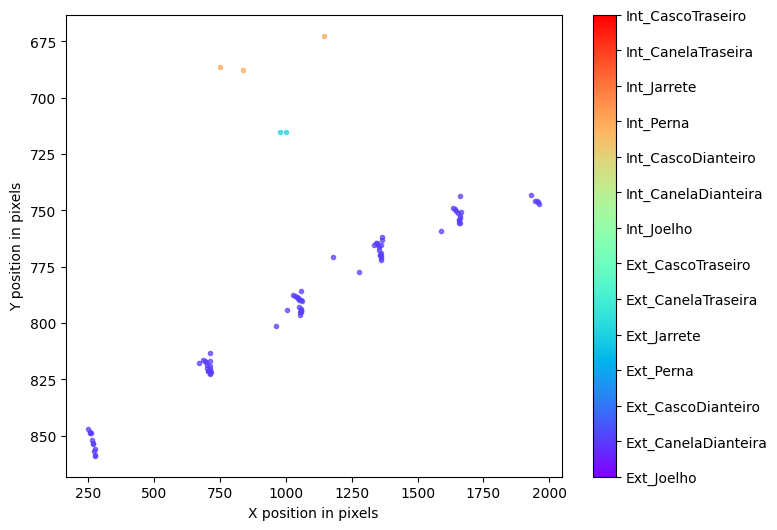

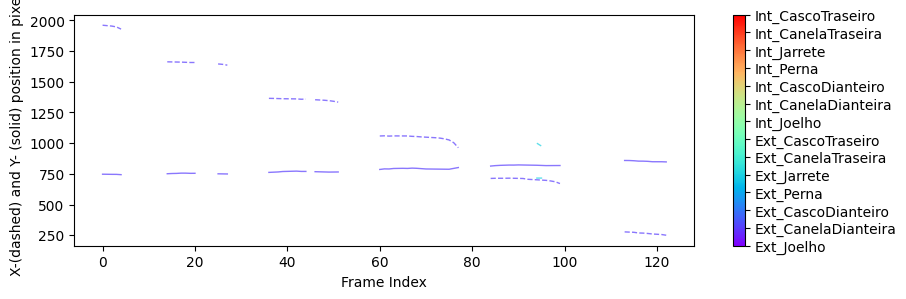

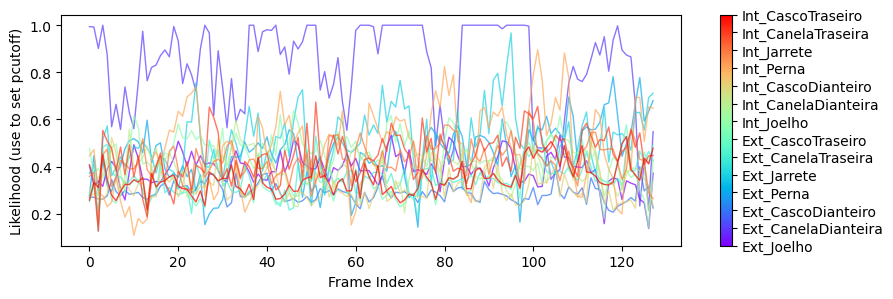

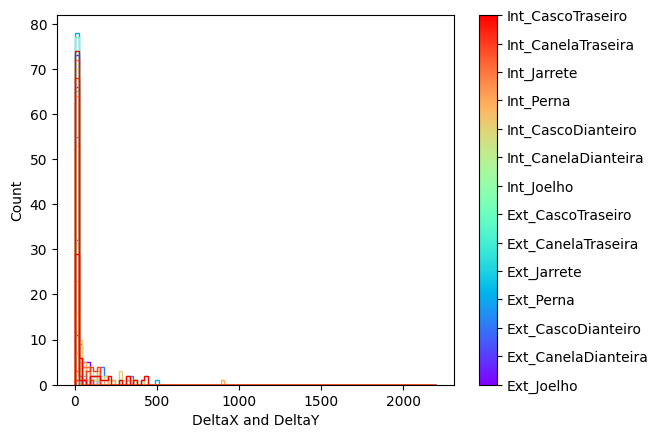

In [7]:
deeplabcut.plot_trajectories(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
)

## Criar vídeo com legendas:
Esta função serve para fins de visualização e pode ser usada para criar um vídeo em formato .mp4 com rótulos previstos pela rede. Este vídeo é salvo no mesmo diretório onde o vídeo original está localizado.

In [8]:
deeplabcut.create_labeled_video(
    path_config_file,
    videofile_path,
    videotype='.mp4',
    destfolder=destfolder,
)

Starting to process video: /content/EstimativaPose_LOCAL/videos/1.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/3.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/2.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/4.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/5.mp4Starting to process video: /content/EstimativaPose_LOCAL/videos/6.mp4

Starting to process video: /content/EstimativaPose_LOCAL/videos/7.mp4


Loading /content/EstimativaPose_LOCAL/videos/1.mp4 and data.Loading /content/EstimativaPose_LOCAL/videos/2.mp4 and data.
Loading /content/EstimativaPose_LOCAL/videos/4.mp4 and data.
Loading /content/EstimativaPose_LOCAL/videos/5.mp4 and data.
Starting to process video: /content/EstimativaPose_LOCAL/videos/8.mp4
Loading /content/EstimativaPose_LOCAL/videos/6.mp4 and data.Loading /content/EstimativaPose_LOCAL/videos/3.mp4 and data.

Loading /content/EstimativaPose_LOCAL/videos/7.mp4 and data.

Loading /conten

  0%|          | 0/78 [00:00<?, ?it/s]


Generating frames and creating video.Overall # of frames: 54 with cropped frame dimensions: 2208 1242

  0%|          | 0/49 [00:00<?, ?it/s]


Overall # of frames: 44 with cropped frame dimensions: 2208 1242

Generating frames and creating video.Generating frames and creating video.

...

100%|██████████| 49/49 [00:02<00:00, 17.71it/s]

Overall # of frames: 128 with cropped frame dimensions: 2208 1242


Generating frames and creating video.


100%|██████████| 128/128 [00:03<00:00, 37.84it/s]


[True, True, True, True, True, True, True, True, True, True]

## Gráfico de Confiança (Likelihood)

Exibindo diagnóstico: /content/EstimativaPose_LOCAL/labeled-videos/plot-poses/5/plot-likelihood.png


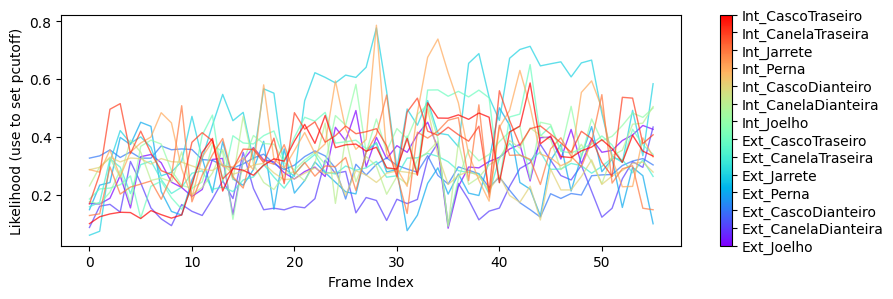

In [10]:
import os
from IPython.display import Image, display

# Busca automática e exibição direta
encontrado = False
for root, dirs, files in os.walk(f"/content/EstimativaPose_LOCAL"):
    for file in files:
        if "likelihood" in file.lower() and file.endswith(".png"):
            caminho = os.path.join(root, file)
            print(f"Exibindo diagnóstico: {caminho}")
            display(Image(filename=caminho))
            encontrado = True
            break # Mostra apenas o primeiro para não encher a tela
    if encontrado: break

if not encontrado:
    print("Gráfico não encontrado. Rode: deeplabcut.plot_trajectories(path_config_file, videofile_path, destfolder=destfolder)")

## Cria gráfico Loss


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

csv_path = "/content/EstimativaPose_BACKUP/dlc-models-pytorch/iteration-0/EstimativaPoseMar6-trainset95shuffle1/train/learning_stats.csv"

if os.path.exists(csv_path):
    # Lendo o CSV e garantindo que os dados sejam numéricos
    try:
        data = pd.read_csv(csv_path, header=None)

        # O DLC salva 3 colunas: Iteração, Loss, LR
        # Vamos converter para numérico, transformando erros em 'NaN' e depois removendo-os
        data[0] = pd.to_numeric(data[0], errors='coerce')
        data[1] = pd.to_numeric(data[1], errors='coerce')
        data = data.dropna()

        plt.figure(figsize=(12, 6))
        plt.plot(data[0], data[1], color='teal', linewidth=2, label='Treinamento (Loss)')

        plt.title('Curva de Aprendizado - Estimativa de Pose (Cavalos)', fontsize=14)
        plt.xlabel('Iterações', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)

        # Escala logarítmica é melhor para ver o Loss chegando perto de zero
        plt.yscale('log')
        plt.legend()

        plt.show()
        print(f"Gráfico gerado! Total de pontos processados: {len(data)}")

    except Exception as e:
        print(f"Erro ao processar os dados: {e}")
else:
    print("Arquivo learning_stats.csv não encontrado no caminho.")

Arquivo learning_stats.csv não encontrado no caminho.


In [13]:
# Envia pasta com arquivos para o drive
# Remove a versão antiga do Drive para evitar duplicatas ou lixo
!rm -rf /content/drive/MyDrive/deeplabcut/EstimativaPose_LOCAL

# Copia a pasta atualizada do Colab para a raiz Drive
!cp -r /content/EstimativaPose_LOCAL /content/drive/MyDrive/deeplabcut